# Notebook 2 - Clustering

This notebook continues from the preprocessing choices in `nb_1`. Reusable logic stays in `functions/clustering.py`; this notebook is for comparison tables, plots, and cluster interpretation.

In [ ]:
import os
import sys
import warnings
from pathlib import Path

def _find_project_root(start, marker="requirements.txt"):
    path = Path(start).resolve()
    for candidate in [path] + list(path.parents):
        if (candidate / marker).exists():
            return str(candidate)
    raise RuntimeError(f"Could not find project root (marker={marker!r}, searched from {start})")

PROJECT_ROOT = _find_project_root(os.path.abspath("."))
os.chdir(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

: 

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
from functions.preprocessing import FEATURE_COLS, preprocessing, scale_features
from functions.clustering import (
    add_clusters,
    cluster_lift_profile,
    cluster_mean_profile,
    cluster_size_summary,
    compare_clustering_models,
    compare_dbscan,
    compare_stability,
    compare_kmeans_inertia,
    export_cluster_profile,
    export_customer_clusters,
    fit_final_kmeans,
    plot_cluster_feature_heatmap,
    plot_dbscan_outliers,
    plot_metric_comparison,
    plot_pca_cluster_map,
    plot_umap_cluster_map,
    top_cluster_differences,
    plot_dbscan_outliers, 
    plot_dbscan_knn_distance)

## Load Preprocessed Features

In [47]:
customer_info = pd.read_csv('data/customer_info.csv')
customer_basket = pd.read_csv('data/customer_basket.csv')
customer_features = preprocessing(customer_info)
customer_scaled, scaler = scale_features(customer_features)

print(f'{customer_features.shape[0]:,} customers')
print(f'{len(FEATURE_COLS)} clustering features')
display(customer_scaled[FEATURE_COLS].head())

33,038 customers
21 clustering features


,age,is_female,dependants,has_loyalty_card,customer_tenure,distinct_stores_visited,typical_hour,percentage_of_products_bought_promotion,lifetime_total_distinct_products,number_complaints,...,share_groceries,share_electronics,share_vegetables,share_nonalcohol_drinks,share_alcohol_drinks,share_meat,share_fish,share_hygiene,share_videogames,share_petfood
0,0.03125,0.0,0.0,0.0,-0.714286,0.0,0.000,1.147251,0.461538,0.0,...,-0.350008,1.538609,-0.020252,-0.096317,-0.416981,-0.889505,-0.382116,-0.029743,0.311244,0.399106
1,-0.12500,0.0,-1.0,0.0,0.285714,-0.5,0.000,-0.262009,0.048951,-1.0,...,-0.130392,-0.228320,1.686147,0.440933,-0.574071,-0.870557,-0.744750,1.679631,0.530567,1.236579
2,0.00000,-1.0,-2.0,-1.0,1.428571,-0.5,-0.125,-0.498290,-0.293706,-1.0,...,0.450655,-0.654518,0.315733,-0.748057,-0.479881,1.554479,-0.175710,0.049021,-0.282499,-0.038382
3,-0.34375,-1.0,-2.0,0.0,-0.857143,-1.0,0.750,0.041426,-0.216783,1.0,...,-0.973212,0.007254,-0.330816,1.895790,1.739674,1.054119,1.681191,0.044439,8.226201,-0.173590
4,0.06250,-1.0,-2.0,0.0,-0.857143,-1.0,0.625,-0.154704,-0.818182,2.0,...,-1.668903,3.108581,-0.134922,0.237569,0.179075,0.331545,0.561586,-0.521282,3.167192,0.154859


## Candidate Model Comparison

K-Means and Ward hierarchical clustering are compared on the same reproducible sample. The chosen model is fitted on the full customer base.

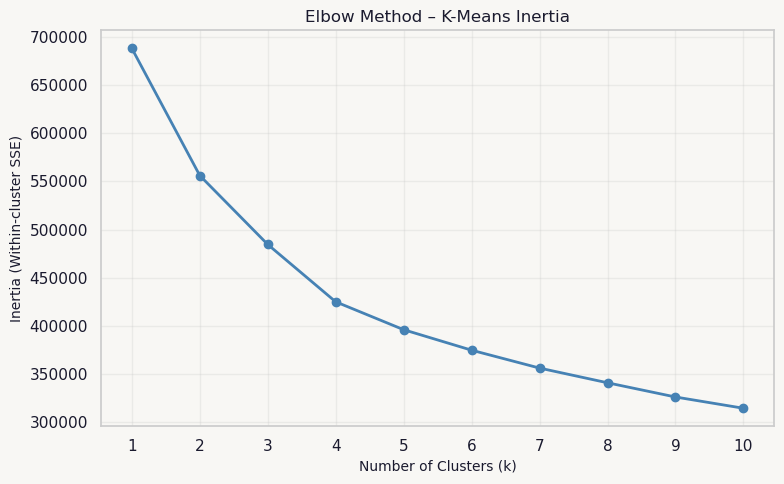

In [48]:
inertia_df = compare_kmeans_inertia(customer_scaled, FEATURE_COLS)

,model,k,silhouette
0,kmeans,3,0.274393
1,hierarchical_ward,3,0.254215
2,kmeans,4,0.230277
3,kmeans,5,0.212092
4,kmeans,6,0.208935
5,hierarchical_ward,4,0.186747
6,hierarchical_ward,5,0.181630
7,hierarchical_ward,6,0.179871
8,kmeans,8,0.152700
9,kmeans,7,0.148250


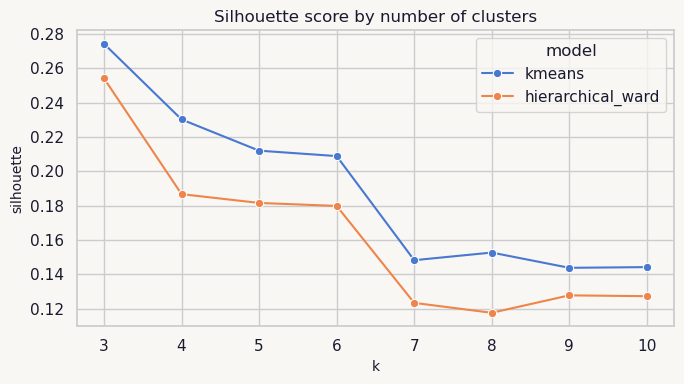

In [49]:
model_results = compare_clustering_models(customer_scaled, FEATURE_COLS)

display(model_results)
plot_metric_comparison(model_results)

In [50]:
kmeans_stability = compare_stability(customer_scaled, FEATURE_COLS, k_range=range(3, 11),
                                            seeds=range(5))

display(kmeans_stability)

,k,silhouette_mean,silhouette_std
0,3,0.274393,0.000000
1,4,0.230247,0.000042
2,5,0.211564,0.001361
3,6,0.196960,0.028157
4,9,0.155092,0.000184
5,8,0.149221,0.008491
6,7,0.147734,0.000302
7,10,0.144269,0.001064


## DBSCAN Diagnostic

DBSCAN is used as an outlier/noise diagnostic, not as the main segmentation model.

In [51]:
dbscan_results = compare_dbscan(
    customer_scaled,
    FEATURE_COLS,
    eps_values=(1.5, 2.0, 2.5, 3.0, 3.5),
    min_samples_values=(10, 25, 50))

display(dbscan_results)

,eps,min_samples,n_clusters,noise_share,silhouette
0,2.5,50,2,0.315,0.390567
1,1.5,10,2,0.958,0.338749
2,2.0,10,4,0.539,0.257576
3,2.0,50,4,0.809,0.252276
4,2.5,25,3,0.246,0.202742
5,2.5,10,3,0.201,0.188302
6,2.0,25,3,0.692,0.103170
7,1.5,25,0,1.000,NaN
8,1.5,50,0,1.000,NaN
9,3.0,10,1,0.094,NaN


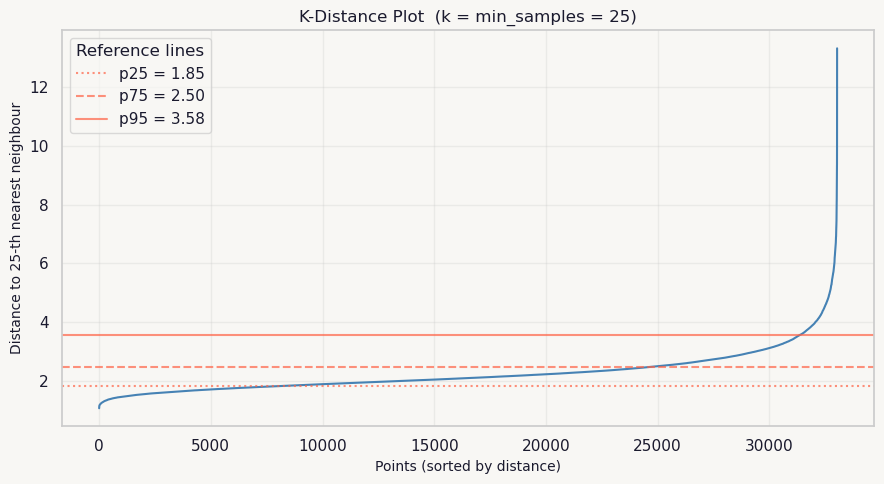

Suggested eps range  →  p75: 2.50  |  p95: 3.58


array([ 1.08764735,  1.12551637,  1.1278191 , ..., 10.98494585,
       12.00762581, 13.30176305], shape=(33038,))

In [52]:
kth_dist = plot_dbscan_knn_distance(customer_scaled, FEATURE_COLS, min_samples=25)
kth_dist

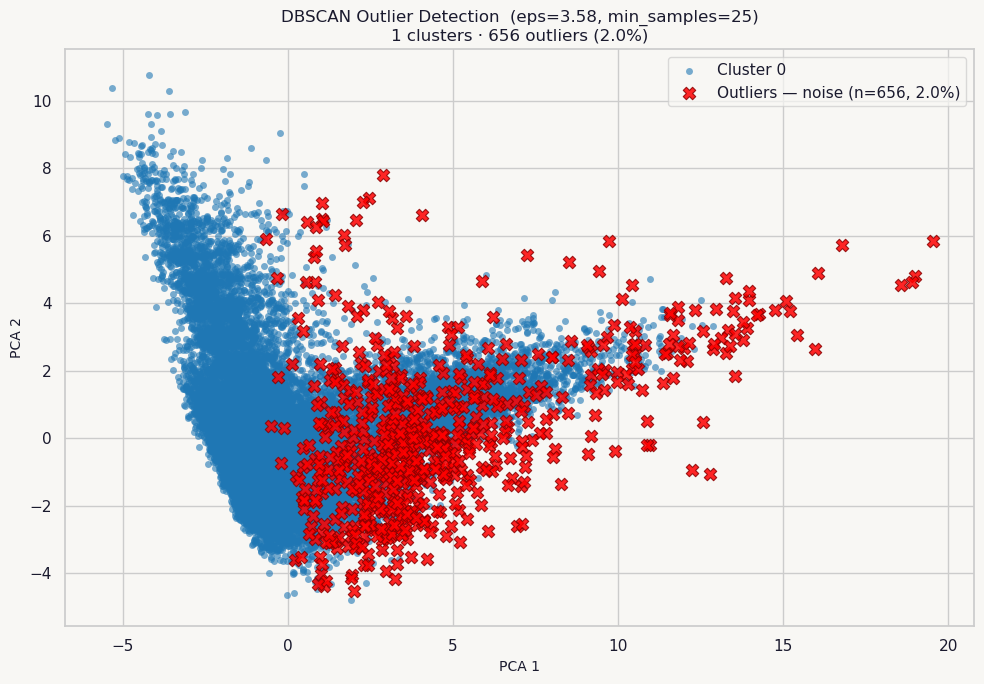

array([0, 0, 0, ..., 0, 0, 0], shape=(33038,))

In [53]:
labels = plot_dbscan_outliers(customer_scaled, FEATURE_COLS, eps=3.58, min_samples=25)
labels

## Selected Candidate

`k=5` is kept as the current working candidate: it gives interpretable segments while avoiding the oversized single segment created by `k=3`.

In [54]:
selected_k = 5

labels, kmeans_model = fit_final_kmeans(customer_scaled, FEATURE_COLS, n_clusters=selected_k)

customer_clustered = add_clusters(customer_features, labels)
display(cluster_size_summary(customer_clustered))

,cluster,n_customers,customer_share
0,0,5427,0.1643
1,1,18400,0.5569
2,2,3550,0.1075
3,3,2971,0.0899
4,4,2690,0.0814


In [ ]:
profile_cols = [
    'age',
    'is_female',
    'dependants',
    'has_loyalty_card',
    'customer_tenure',
    'distinct_stores_visited',
    'typical_hour',
    'percentage_of_products_bought_promotion',
    'lifetime_total_distinct_products',
    'number_complaints',
    'total_spend',
    'share_groceries',
    'share_electronics',
    'share_vegetables',
    'share_nonalcohol_drinks',
    'share_alcohol_drinks',
    'share_meat',
    'share_fish',
    'share_hygiene',
    'share_videogames',
    'share_petfood']

display(cluster_mean_profile(customer_clustered, profile_cols))
display(cluster_lift_profile(customer_clustered, profile_cols))
display(top_cluster_differences(customer_clustered, profile_cols, top_n=4))

,cluster,n_customers,customer_share,age,is_female,dependants,has_loyalty_card,customer_tenure,distinct_stores_visited,typical_hour,...,share_groceries,share_electronics,share_vegetables,share_nonalcohol_drinks,share_alcohol_drinks,share_meat,share_fish,share_hygiene,share_videogames,share_petfood
0,0,5427,0.1643,57.565,0.490,1.900,0.578,10.256,3.418,12.292,...,0.570,0.098,0.127,0.037,0.021,0.008,0.007,0.096,0.012,0.024
1,1,18400,0.5569,53.432,0.503,1.634,0.611,10.860,3.291,12.262,...,0.760,0.065,0.024,0.016,0.024,0.032,0.024,0.030,0.009,0.015
2,2,3550,0.1075,56.460,0.519,0.650,0.494,8.917,1.661,16.905,...,0.365,0.366,0.014,0.025,0.048,0.041,0.037,0.016,0.074,0.015
3,3,2971,0.0899,57.422,0.487,6.410,0.675,12.771,3.214,10.240,...,0.653,0.136,0.022,0.023,0.042,0.041,0.036,0.026,0.012,0.010
4,4,2690,0.0814,57.418,0.511,1.552,0.669,11.165,3.743,13.026,...,0.441,0.129,0.049,0.039,0.047,0.092,0.064,0.074,0.024,0.041


,age,is_female,dependants,has_loyalty_card,customer_tenure,distinct_stores_visited,typical_hour,percentage_of_products_bought_promotion,lifetime_total_distinct_products,number_complaints,...,share_groceries,share_electronics,share_vegetables,share_nonalcohol_drinks,share_alcohol_drinks,share_meat,share_fish,share_hygiene,share_videogames,share_petfood
cluster,,,,,,,,,,,,,,,,,,,,,
0,1.044,0.976,0.953,0.959,0.954,1.079,0.972,0.423,0.698,0.713,...,0.876,0.853,3.040,1.625,0.723,0.237,0.270,2.245,0.648,1.319
1,0.969,1.002,0.819,1.012,1.010,1.039,0.970,1.192,0.986,1.040,...,1.168,0.571,0.574,0.690,0.804,0.926,0.897,0.711,0.516,0.823
2,1.024,1.035,0.326,0.818,0.830,0.524,1.337,0.846,0.713,1.152,...,0.561,3.198,0.341,1.119,1.629,1.161,1.354,0.373,4.101,0.812
3,1.042,0.970,3.213,1.118,1.188,1.015,0.810,0.676,1.974,1.051,...,1.003,1.185,0.537,1.006,1.430,1.168,1.318,0.611,0.640,0.572
4,1.042,1.019,0.778,1.109,1.039,1.182,1.030,1.412,1.005,1.050,...,0.678,1.129,1.178,1.693,1.595,2.643,2.359,1.722,1.326,2.287


,cluster,direction,feature,z
0,0,below_average,share_meat,-0.882
1,0,below_average,share_fish,-0.820
2,0,below_average,percentage_of_products_bought_promotion,-0.650
3,0,below_average,total_spend,-0.614
4,0,above_average,share_vegetables,1.631
5,0,above_average,share_hygiene,1.301
6,0,above_average,share_nonalcohol_drinks,0.911
7,0,above_average,share_petfood,0.400
8,1,below_average,share_nonalcohol_drinks,-0.451
9,1,below_average,share_electronics,-0.383


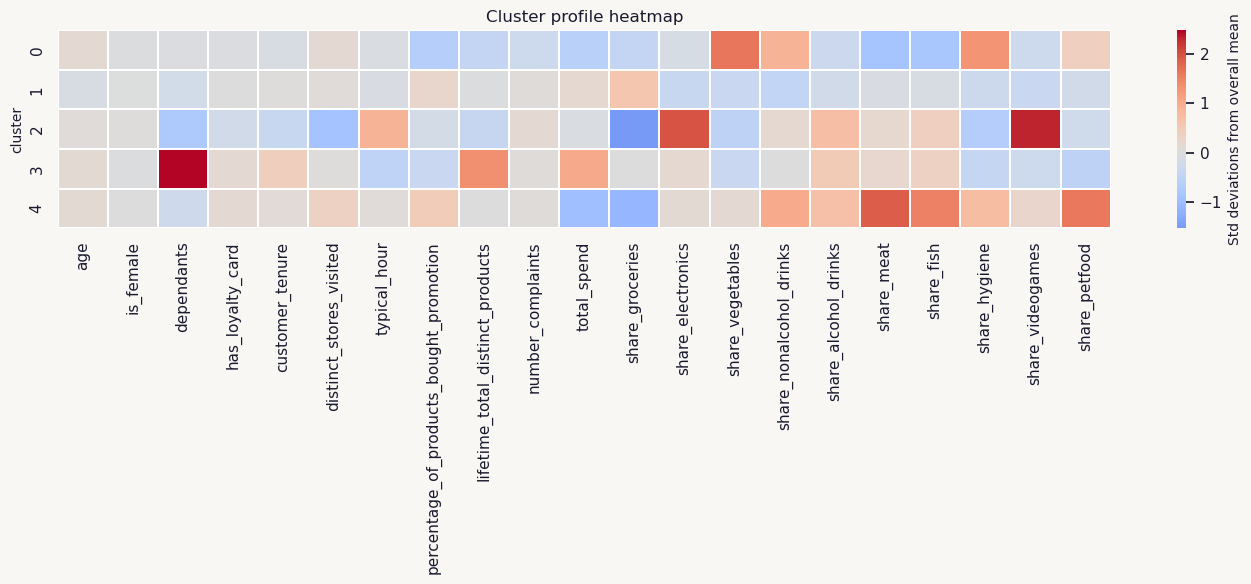

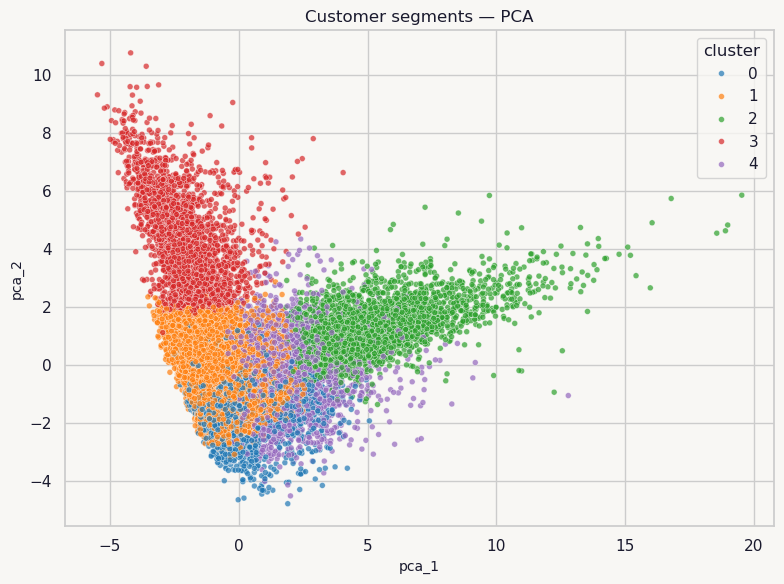

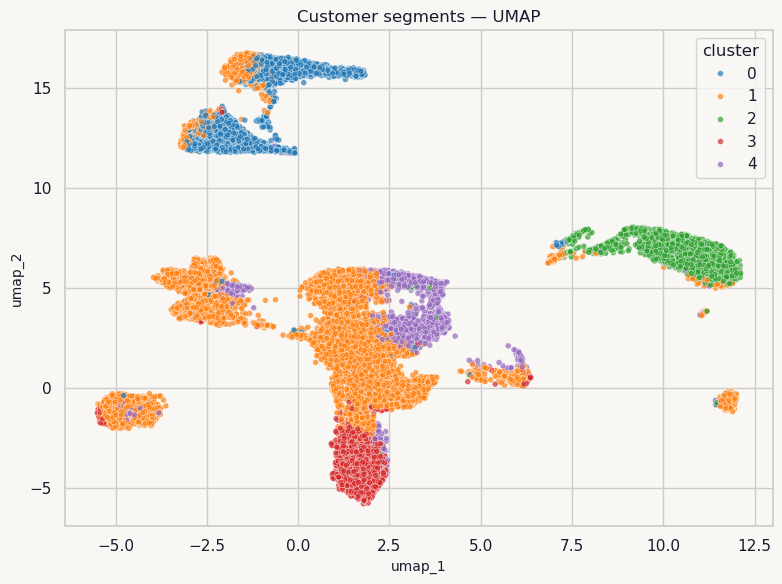

In [57]:
plot_cluster_feature_heatmap(customer_clustered, profile_cols)
plot_pca_cluster_map(customer_scaled, FEATURE_COLS, labels)
plot_umap_cluster_map(customer_scaled, FEATURE_COLS, labels)

# Customer Profiling

In [58]:
# Check what separates cluster 4 from cluster 1
top_cluster_differences(customer_clustered, FEATURE_COLS)


,cluster,direction,feature,z
0,0,below_average,share_meat,-0.882
1,0,below_average,share_fish,-0.820
2,0,below_average,percentage_of_products_bought_promotion,-0.650
3,0,below_average,total_spend,-0.614
4,0,below_average,share_groceries,-0.432
5,0,below_average,lifetime_total_distinct_products,-0.425
6,0,above_average,share_vegetables,1.631
7,0,above_average,share_hygiene,1.301
8,0,above_average,share_nonalcohol_drinks,0.911
9,0,above_average,share_petfood,0.400


In [59]:
# Compare cluster sizes
cluster_size_summary(customer_clustered)

,cluster,n_customers,customer_share
0,0,5427,0.1643
1,1,18400,0.5569
2,2,3550,0.1075
3,3,2971,0.0899
4,4,2690,0.0814


In [60]:
# Visualise lift to see if cluster 4 has a real identity
cluster_lift_profile(customer_clustered, FEATURE_COLS)

,age,is_female,dependants,has_loyalty_card,customer_tenure,distinct_stores_visited,typical_hour,percentage_of_products_bought_promotion,lifetime_total_distinct_products,number_complaints,...,share_groceries,share_electronics,share_vegetables,share_nonalcohol_drinks,share_alcohol_drinks,share_meat,share_fish,share_hygiene,share_videogames,share_petfood
cluster,,,,,,,,,,,,,,,,,,,,,
0,1.044,0.976,0.953,0.959,0.954,1.079,0.972,0.423,0.698,0.713,...,0.876,0.853,3.040,1.625,0.723,0.237,0.270,2.245,0.648,1.319
1,0.969,1.002,0.819,1.012,1.010,1.039,0.970,1.192,0.986,1.040,...,1.168,0.571,0.574,0.690,0.804,0.926,0.897,0.711,0.516,0.823
2,1.024,1.035,0.326,0.818,0.830,0.524,1.337,0.846,0.713,1.152,...,0.561,3.198,0.341,1.119,1.629,1.161,1.354,0.373,4.101,0.812
3,1.042,0.970,3.213,1.118,1.188,1.015,0.810,0.676,1.974,1.051,...,1.003,1.185,0.537,1.006,1.430,1.168,1.318,0.611,0.640,0.572
4,1.042,1.019,0.778,1.109,1.039,1.182,1.030,1.412,1.005,1.050,...,0.678,1.129,1.178,1.693,1.595,2.643,2.359,1.722,1.326,2.287


## Export

In [43]:
customer_clusters = export_customer_clusters(
    customer_clustered,
    output_path='../outputs/customer_clusters.csv',
)
cluster_profile = export_cluster_profile(
    customer_clustered,
    profile_cols,
    output_path='../outputs/cluster_profile.csv',
)

print(f'Exported {len(customer_clusters):,} customer assignments')
display(cluster_profile)

Exported 33,038 customer assignments


,cluster,n_customers,customer_share,age,is_female,household_size,has_loyalty_card,customer_tenure,distinct_stores_visited,typical_hour,...,share_groceries,share_electronics,share_vegetables,share_nonalcohol_drinks,share_alcohol_drinks,share_meat,share_fish,share_hygiene,share_videogames,share_petfood
0,0,5427,0.1643,57.565,0.490,1.900,0.578,10.256,3.418,12.292,...,0.570,0.098,0.127,0.037,0.021,0.008,0.007,0.096,0.012,0.024
1,1,18400,0.5569,53.432,0.503,1.634,0.611,10.860,3.291,12.262,...,0.760,0.065,0.024,0.016,0.024,0.032,0.024,0.030,0.009,0.015
2,2,3550,0.1075,56.460,0.519,0.650,0.494,8.917,1.661,16.905,...,0.365,0.366,0.014,0.025,0.048,0.041,0.037,0.016,0.074,0.015
3,3,2971,0.0899,57.422,0.487,6.410,0.675,12.771,3.214,10.240,...,0.653,0.136,0.022,0.023,0.042,0.041,0.036,0.026,0.012,0.010
4,4,2690,0.0814,57.418,0.511,1.552,0.669,11.165,3.743,13.026,...,0.441,0.129,0.049,0.039,0.047,0.092,0.064,0.074,0.024,0.041
